In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [2]:
df = pd.read_csv("hotel_bookings.csv")

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df["country"] = df["country"].fillna("Unknown")
df["agent"] = df["agent"].fillna(0)
df["company"] = df["company"].fillna(0)

In [5]:
df["arrival_date"] = pd.to_datetime(df["arrival_date_year"].astype(str) + "-" +df["arrival_date_month"] + "-" +
df["arrival_date_day_of_month"].astype(str))

In [6]:
cancel_rate = df.groupby("hotel")["is_canceled"].mean()
cancel_rate

hotel
City Hotel      0.417270
Resort Hotel    0.277634
Name: is_canceled, dtype: float64

In [7]:
pivot = df.pivot_table(values="is_canceled",index="arrival_date_month",columns="hotel",aggfunc="count")

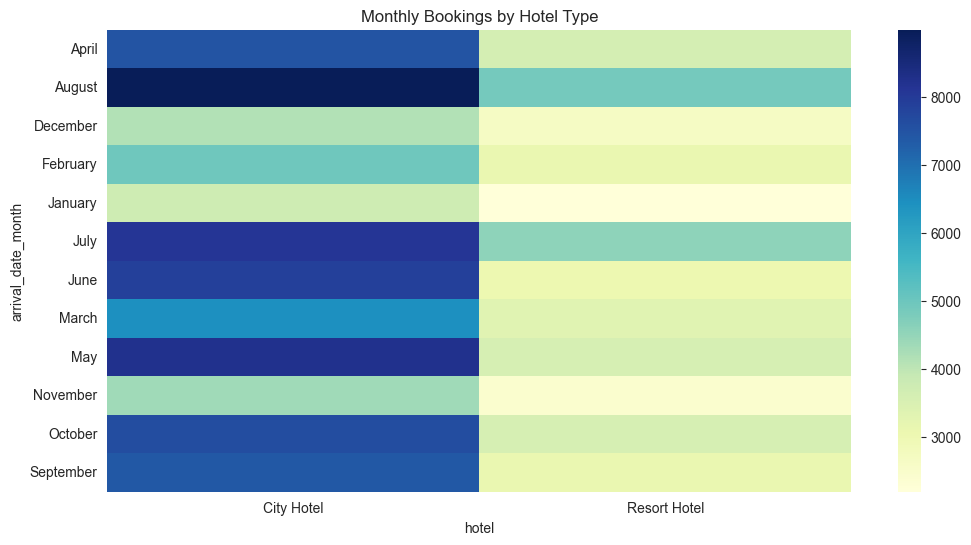

In [8]:
plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="YlGnBu")
plt.title("Monthly Bookings by Hotel Type")
plt.show()

In [9]:
monthly_cancel = df.groupby(["arrival_date_month", "hotel"])["is_canceled"].mean().unstack()
monthly_cancel

hotel,City Hotel,Resort Hotel
arrival_date_month,,
April,0.463235,0.293433
August,0.400980,0.334491
December,0.421104,0.238293
February,0.382880,0.256204
January,0.396681,0.148199
July,0.408754,0.314017
June,0.446922,0.330706
March,0.369464,0.228717
May,0.443756,0.287721


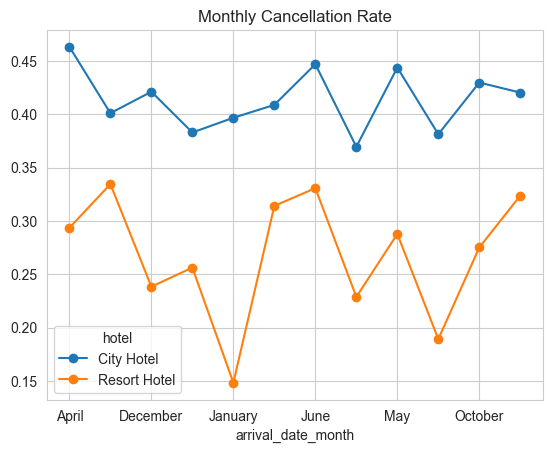

In [10]:
monthly_cancel.plot(marker="o")
plt.title("Monthly Cancellation Rate")
plt.show()


In [11]:
top_countries = df["country"].value_counts().head(10)
top_countries

country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3766
IRL     3375
BEL     2342
BRA     2224
NLD     2104
Name: count, dtype: int64

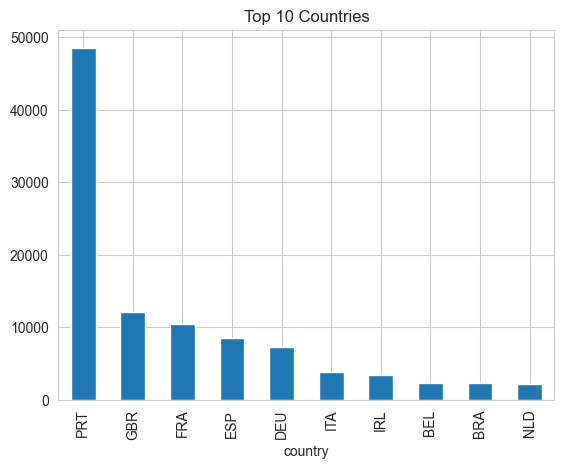

In [12]:
top_countries.plot(kind="bar")
plt.title("Top 10 Countries")
plt.show()

In [13]:
segment = df.groupby("market_segment")["is_canceled"].agg(["count","mean"])
segment

,count,mean
market_segment,,
Aviation,237,0.219409
Complementary,743,0.130552
Corporate,5295,0.187347
Direct,12606,0.153419
Groups,19811,0.610620
Offline TA/TO,24219,0.343160
Online TA,56477,0.367211
Undefined,2,1.000000


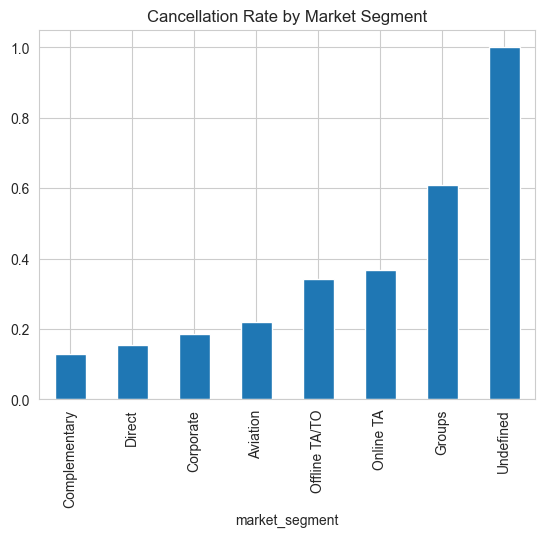

In [14]:
segment["mean"].sort_values().plot(kind="bar")
plt.title("Cancellation Rate by Market Segment")
plt.show()

In [15]:
df.groupby("is_canceled")["lead_time"].mean()

is_canceled
0     79.984687
1    144.848815
Name: lead_time, dtype: float64

In [16]:
adr_month = df.groupby(["arrival_date_month", "hotel"])["adr"].mean().unstack()
adr_month #bonus

hotel,City Hotel,Resort Hotel
arrival_date_month,,
April,111.251838,77.849496
August,114.680455,186.790574
December,88.826307,68.984230
February,85.088278,55.171930
January,82.628986,49.461883
July,110.734292,155.181299
June,119.074341,110.444749
March,92.643116,57.520147
May,121.638560,78.758134


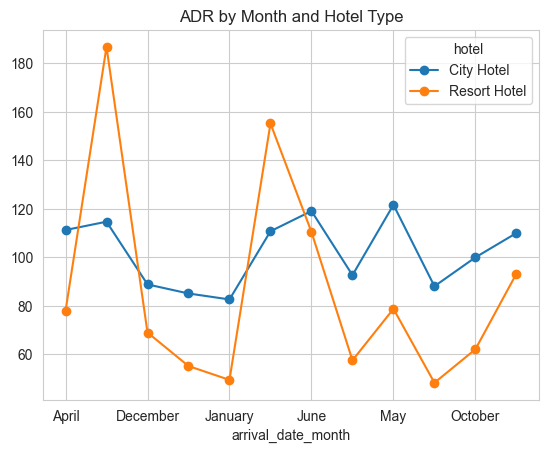

In [17]:
adr_month.plot(marker="o")
plt.title("ADR by Month and Hotel Type")
plt.show()

In [ ]:
segment_cancel = df.groupby("market_segment")["is_canceled"].mean()
segment_cancel #bonus

market_segment
Aviation         0.219409
Complementary    0.130552
Corporate        0.187347
Direct           0.153419
Groups           0.610620
Offline TA/TO    0.343160
Online TA        0.367211
Undefined        1.000000
Name: is_canceled, dtype: float64

In [20]:
best_segment = segment_cancel.idxmin()
best_value = segment_cancel.min()
best_segment, best_value

('Complementary', np.float64(0.13055181695827725))